# RNN temporal analysis

Experimento de forecasting (predição) por meio de RNNs.

* Atividade PEL219 - GLWT MNIST - Gabriel Melo. Matrícula: 125.304-6

In [26]:
import numpy as np
import kagglehub
import pandas as pd

from matplotlib import pyplot as plt
from tensorflow.keras.layers import Dense, LSTM, InputLayer, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Preparing data

In [27]:
# Download the forecasting dataset
path = kagglehub.dataset_download("arashnic/time-series-forecasting-with-yahoo-stock-price")
df = pd.read_csv(path + "/yahoo_stock.csv")
df

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107
...,...,...,...,...,...,...,...
1820,2020-11-16,3628.510010,3600.159912,3600.159912,3626.909912,5.281980e+09,3626.909912
1821,2020-11-17,3623.110107,3588.679932,3610.310059,3609.530029,4.799570e+09,3609.530029
1822,2020-11-18,3619.090088,3567.330078,3612.090088,3567.790039,5.274450e+09,3567.790039
1823,2020-11-19,3585.219971,3543.840088,3559.409912,3581.870117,4.347200e+09,3581.870117


In [28]:
def train_glwt(model: Sequential, X: np.array, Y: np.array, optimizer, loss, _epochs=10, _callbacks=[]):
    histories = []
    
    for i in range(1, len(model.layers)):
        for layer in model.layers[:i]:
            layer.trainable = False
        for layer in model.layers[i:]:
            layer.trainable = True

        model.compile(optimizer, loss, metrics=["mae"])
        
        histories.append(model.fit(x=X, y=Y, epochs=_epochs, validation_split=.1, callbacks=_callbacks))
            
    return histories

In [29]:
def create_sequences(data: np.array, seq_len: int = 5, forecast_len: int = 5):
    """
    create sequence of a original 1d series using a sliding window
    """
    X, y = [], []
    for i in range(len(data) - (seq_len + forecast_len)):
        seek = i+seq_len
        X.append(data[i:seek])
        y.append(data[seek:seek+forecast_len])
    return np.array(X), np.array(y)

In [30]:
values = df["Close"].values

scaler = MinMaxScaler(feature_range=(0, 1))

X, y = create_sequences(values)

X = scaler.fit_transform(X)
y = scaler.transform(y)

X.shape, y.shape

((1815, 5), (1815, 5))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.3)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1270, 5, 1), (1270, 5), (545, 5, 1), (545, 5))

# Forecasting with LSTM

In [32]:
model = Sequential()
model.add(InputLayer((5, 1)))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(48, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16))
model.add(Dense(5))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 48)             │        21,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,461 (154.14 KB)

 Trainable params: 39,461 (154.14 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

histories = train_glwt(model, X_train, y_train, "adam", "mse", _epochs=100, _callbacks=[es])

for layer in model.layers:
    layer.trainable = True

model.compile("adam", "mse", metrics=["mae"])
model.fit(x=X_train, y=y_train, epochs=100, validation_split=.1, callbacks=[es])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0437 - mae: 0.1602 - val_loss: 0.0112 - val_mae: 0.0992
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - mae: 0.0646 - val_loss: 0.0032 - val_mae: 0.0530
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0451 - val_loss: 7.9623e-04 - val_mae: 0.0235
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - mae: 0.0360 - val_loss: 5.5820e-04 - val_mae: 0.0190
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - mae: 0.0330 - val_loss: 4.7102e-04 - val_mae: 0.0170
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - mae: 0.0317 - val_loss: 4.3634e-04 - val_mae: 0.0160
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0316 - val_loss: 4.5821e-04 - val_mae: 0.0167
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017 - mae: 0.0304 - val_loss: 5.2711e-04 - val_mae: 0.0184
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0

## Testing

In [34]:
results = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [35]:
mae = mean_absolute_error(y_test, results)
mse = mean_squared_error(y_test, results)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - results) / y_test)) * 100  # MAPE is in percentage
r2 = r2_score(y_test, results)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2: {r2}")

MAE: 0.04426185538284025
MSE: 0.0031148220707753554
RMSE: 0.05581059102693104
MAPE: 6.600147693049384
R2: 0.8399777993543746


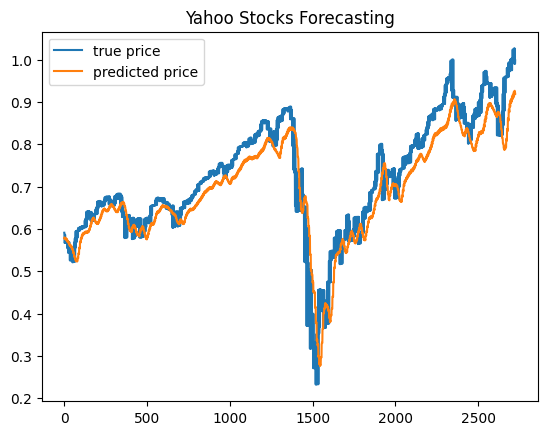

In [36]:
fig = plt.subplot(1,1,1)
fig.plot(y_test.flatten(), label="true price")
fig.plot(results.flatten(), label="predicted price")    
        
plt.title("Yahoo Stocks Forecasting")
plt.legend()

plt.show()

## Training data

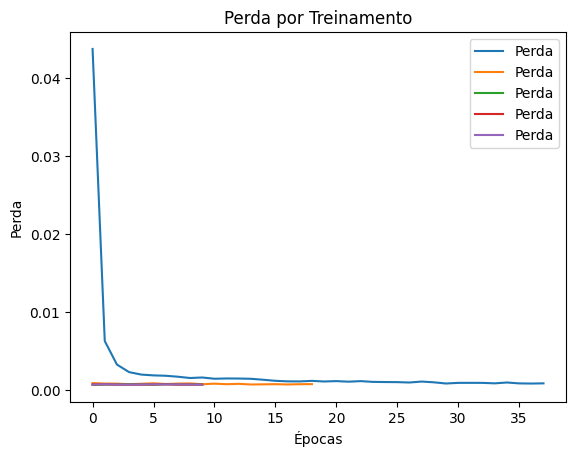

In [37]:
fig = plt.subplot(1,1,1)

for hist in histories:
    fig.plot(hist.history['loss'], label=f'Perda')
        
plt.title("Perda por Treinamento")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()

plt.show()

# Forecasting with GRU

In [38]:
model = Sequential()
model.add(InputLayer((5, 1)))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(GRU(48, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16))
model.add(Dense(5))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 5, 64)          │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 48)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,149 (117.77 KB)

 Trainable params: 30,149 (117.77 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

histories = train_glwt(model, X_train, y_train, "adam", "mse", _epochs=100, _callbacks=[es])

for layer in model.layers:
    layer.trainable = True

model.compile("adam", "mse", metrics=["mae"])
model.fit(x=X_train, y=y_train, epochs=100, validation_split=.1, callbacks=[es])

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0238 - mae: 0.1114 - val_loss: 0.0061 - val_mae: 0.0739
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - mae: 0.0487 - val_loss: 0.0012 - val_mae: 0.0292
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - mae: 0.0385 - val_loss: 7.6201e-04 - val_mae: 0.0227
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022 - mae: 0.0351 - val_loss: 4.4705e-04 - val_mae: 0.0174
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - mae: 0.0329 - val_loss: 5.5028e-04 - val_mae: 0.0199
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - mae: 0.0325 - val_loss: 9.5618e-04 - val_mae: 0.0276
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - mae: 0.0322 - val_loss: 0.0010 - val_mae: 0.0288
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017 - mae: 0.0305 - val_loss: 0.0011 - val_mae: 0.0296
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

## Testing

In [40]:
results = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [41]:
mae = mean_absolute_error(y_test, results)
mse = mean_squared_error(y_test, results)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - results) / y_test)) * 100  # MAPE is in percentage
r2 = r2_score(y_test, results)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"R2: {r2}")

MAE: 0.04639756355746667
MSE: 0.003316747940785996
RMSE: 0.05759121409369659
MAPE: 6.762383294401767
R2: 0.8296200070221795


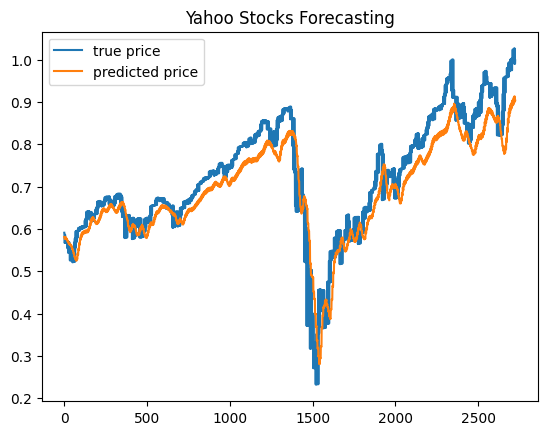

In [42]:
fig = plt.subplot(1,1,1)
fig.plot(y_test.flatten(), label="true price")
fig.plot(results.flatten(), label="predicted price")    
        
plt.title("Yahoo Stocks Forecasting")
plt.legend()

plt.show()

## Training data

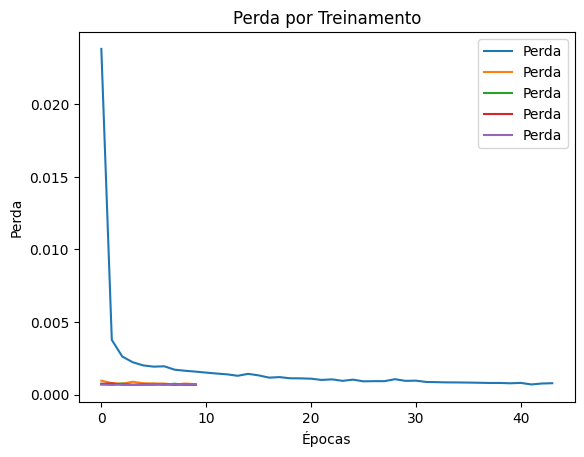

In [43]:
fig = plt.subplot(1,1,1)

for hist in histories:
    fig.plot(hist.history['loss'], label=f'Perda')
        
plt.title("Perda por Treinamento")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()

plt.show()